# 8.3 期限结构套利：Carry 策略与 Calendar Spread

## 为什么期限结构形状本身就是一个交易信号？

在上一节我们学到：Roll Yield 直接影响持有期货的实际收益。
如果Roll Yield 持续为正（Backwardation），持有者每月都在被动赚钱；
如果持续为负（Contango），每月都在被动亏钱。

**关键洞察**：我们可以把 Roll Yield 变成一个**主动交易信号**：
- 买入 Backwardation 最强的品种（被动赚取展期收益）
- 做空 Contango 最强的品种（避免展期成本并可能获利）

这就是 **Carry 策略**——期货市场最经典的因子之一。

## 学习目标
- 理解期限结构斜率作为 Carry 因子的经济学依据
- 实现 Calendar Spread（日历价差）套利策略
- 理解 Carry 策略的风险：供需冲击可能导致期限结构瞬间翻转


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
print('OK')


OK


In [5]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 第一部分：期限结构形状的三种解读

**期限结构（Term Structure）**是不同到期月份期货价格连成的曲线。

| 形状 | 经济含义 | Carry 信号 |
|------|---------|-----------|
| 向上倾斜（Contango）| 未来供给充裕，现货不紧缺 | 做空 → 展期获利 |
| 向下倾斜（Backwardation）| 现货紧缺，立刻需要 | 做多 → 展期获利 |
| 平坦 | 供需均衡 | 无明显套利机会 |

**Carry 因子的来源**

在期货市场中，Carry = Roll Yield（展期收益率）：
$$\text{Carry}_t = \frac{F_{\text{近月}} - F_{\text{次近月}}}{F_{\text{近月}}} \times \frac{1}{\Delta T}$$

持有 Carry 高的品种，每月被动赚取正的展期收益。
这不需要价格移动，只需要期限结构保持稳定——这是 Carry 策略的理想情形。


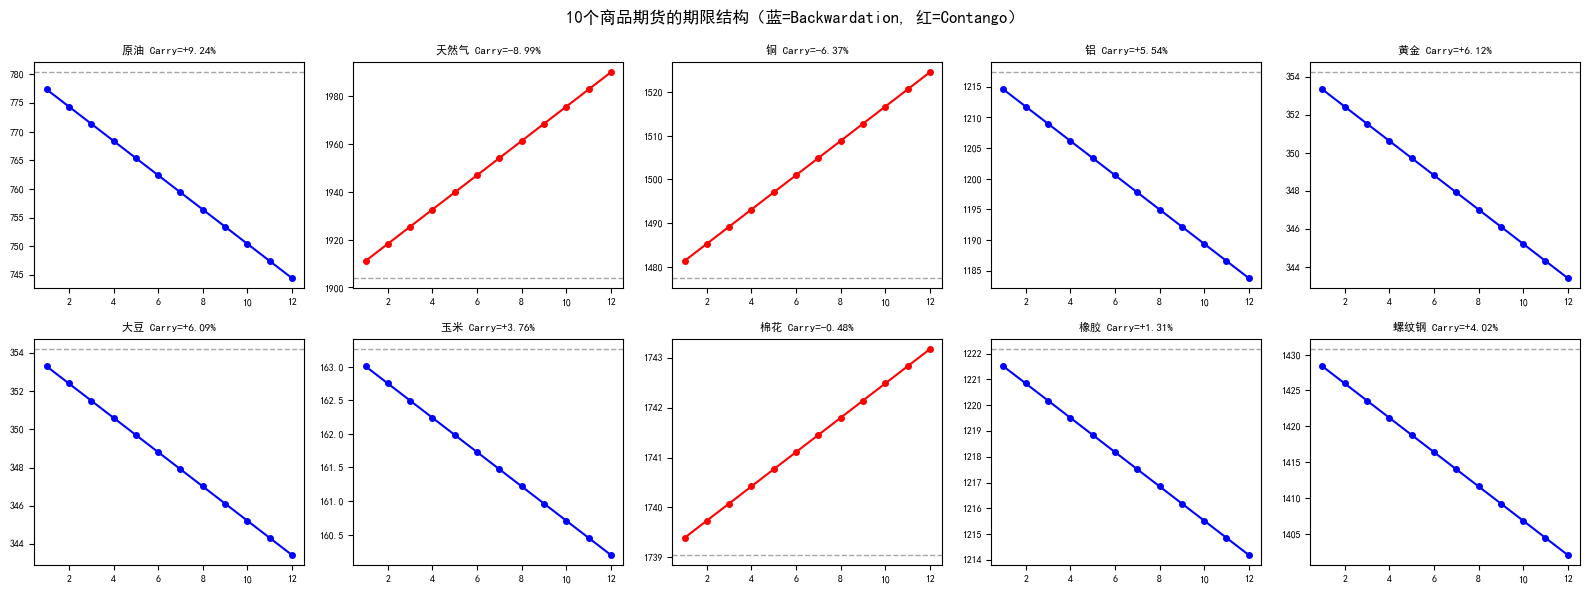

Carry 排名（年化）：
多头（做多最高Carry）:
  原油: +9.24%
  黄金: +6.12%
  大豆: +6.09%
空头（做空最低Carry）:
  棉花: -0.48%
  铜: -6.37%
  天然气: -8.99%


In [7]:
# 模拟 10 个商品品种的期限结构
np.random.seed(42)
n_commodities = 10
commodity_names = ['原油','天然气','铜','铝','黄金','大豆','玉米','棉花','橡胶','螺纹钢']
spot_prices = np.random.uniform(50, 2000, n_commodities)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
carries = []
for ax, name, S0 in zip(axes.flat, commodity_names, spot_prices):
    # 随机生成期限结构斜率
    slope = np.random.uniform(-0.8, 0.8)  # 负=Backwardation, 正=Contango
    months = np.arange(1, 13)
    F = S0 * (1 + slope * months * 0.005)
    carry = (F[0] - F[2]) / F[0] * 12  # 年化 Carry
    carries.append((name, carry))
    color = 'blue' if slope < 0 else 'red'
    ax.plot(months, F, 'o-', color=color, ms=4, lw=1.5)
    ax.axhline(S0, color='gray', lw=1, linestyle='--', alpha=0.7)
    ax.set_title(f'{name} Carry={carry:+.2%}', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('10个商品期货的期限结构（蓝=Backwardation, 红=Contango）', fontsize=12)
plt.tight_layout(); plt.show()

carries.sort(key=lambda x:x[1], reverse=True)
print('Carry 排名（年化）：')
print('多头（做多最高Carry）:')
for name, c in carries[:3]: print(f'  {name}: {c:+.2%}')
print('空头（做空最低Carry）:')
for name, c in carries[-3:]: print(f'  {name}: {c:+.2%}')


## 第二部分：Calendar Spread——利用期限结构均值回归

**Calendar Spread（日历价差）** = 近月合约价格 - 远月合约价格

在 Contango 中：价差 < 0（远月贵）
在 Backwardation 中：价差 > 0（近月贵）

**套利逻辑**：当价差偏离历史均值时，势必有均值回归的倾向。
极端 Contango 往往预示着供给紧张预期会松动 → 价差收窄。

**Calendar Spread 策略的操作**：
- 当价差**远高于均值**（极端 Backwardation）：做空价差（卖近月买远月）
- 当价差**远低于均值**（极端 Contango）：做多价差（买近月卖远月）


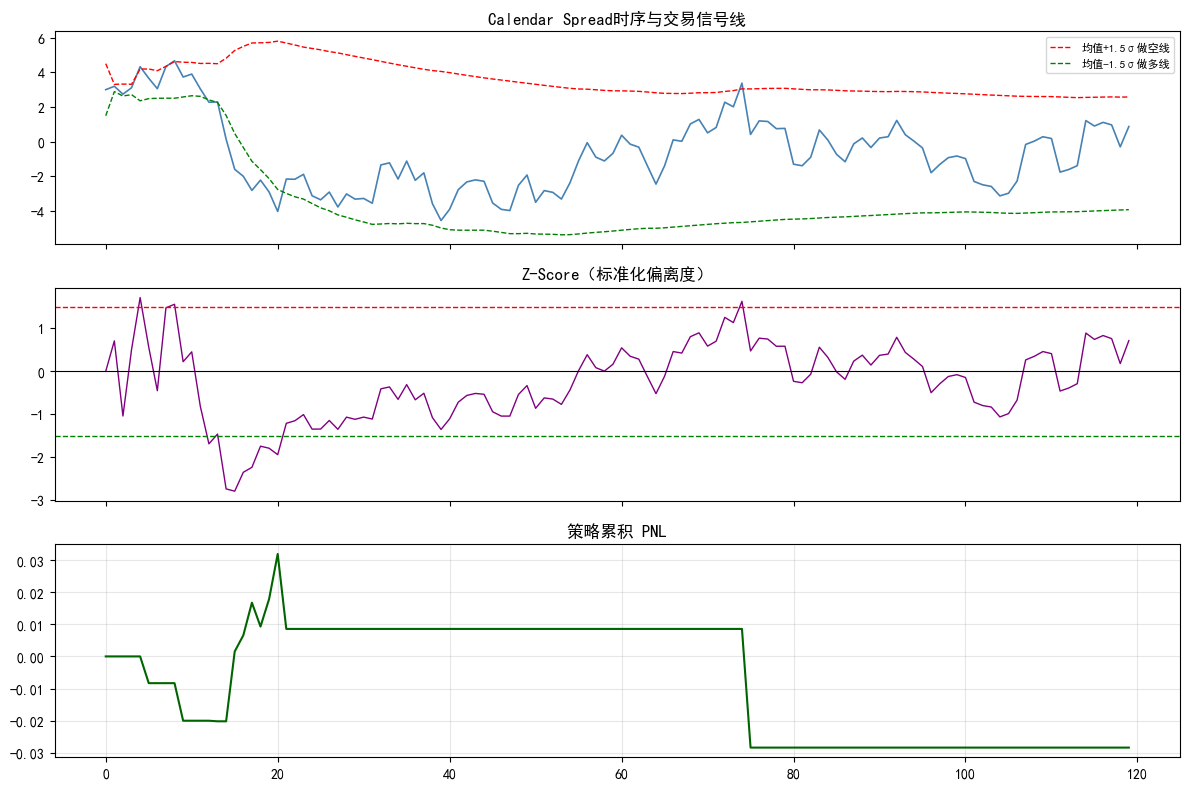

In [8]:
np.random.seed(42)
n = 120  # 120个月

# 模拟Calendar Spread时序（有均值回归特性）
spread = np.zeros(n)
spread[0] = 3.0  # 初始价差 $3
for t in range(1, n):
    mean_rev = 0.1 * (0 - spread[t-1])  # 均值回归项
    noise = np.random.normal(0, 1.0)
    spread[t] = spread[t-1] + mean_rev + noise

spread_s = pd.Series(spread)
roll_mean = spread_s.expanding().mean()
roll_std  = spread_s.expanding().std().fillna(1)
zscore    = (spread_s - roll_mean) / roll_std

# 策略: Z>1.5做空, Z<-1.5做多
signal = pd.Series(0.0, index=spread_s.index)
signal[zscore >  1.5] = -1  # 价差过高 → 做空（期待收窄）
signal[zscore < -1.5] =  1  # 价差过低 → 做多（期待扩张）

pnl = signal.shift(1) * (-spread_s.diff()) / 80  # 归一化PNL

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
spread_s.plot(ax=axes[0], color='steelblue', lw=1.2)
(roll_mean + 1.5*roll_std).plot(ax=axes[0], color='red', lw=1, linestyle='--', label='均值+1.5σ做空线')
(roll_mean - 1.5*roll_std).plot(ax=axes[0], color='green', lw=1, linestyle='--', label='均值-1.5σ做多线')
axes[0].set_title('Calendar Spread时序与交易信号线'); axes[0].legend(fontsize=8)

zscore.plot(ax=axes[1], color='purple', lw=1)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axhline(1.5, color='red', lw=1, linestyle='--')
axes[1].axhline(-1.5, color='green', lw=1, linestyle='--')
axes[1].set_title('Z-Score（标准化偏离度）')

pnl.fillna(0).cumsum().plot(ax=axes[2], color='darkgreen', lw=1.5)
axes[2].set_title('策略累积 PNL'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 🎯 练习

1. 对 WTI 和 Brent 原油期货间的价差数据，设计一个跨品种套利（同种商品不同市场）策略。
2. 用 VIX 期货Term Structure，计算 VIX3M/VIX 的比值作为做空波动率信号的基础，分析历史胜率。
3. Calendar Spread 在自然灾害（如飓风影响墨西哥湾原油产量）时会如何？设计极端事件的风险管理规则。

---
**下一节** → `../09_hft/01_order_book_basics.ipynb`